## Subagents
A deep agent can create subagents to delegate work. You can specify custom subagents in the subagents parameter. Subagents are useful for context quarantine (keeping the main agent’s context clean) and for providing specialized instructions. This page covers synchronous subagents, where the supervisor blocks until the subagent finishes. For long-running tasks, parallel workstreams, or cases where you need mid-flight steering and cancellation, see Async subagents.

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [4]:
from langchain_groq import ChatGroq

model = ChatGroq(
    model="openai/gpt-oss-20b"
)

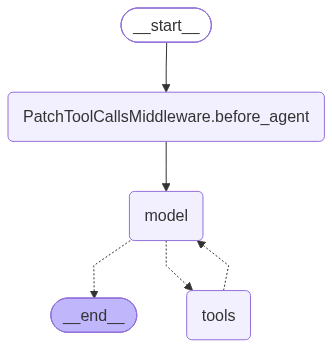

In [5]:
import os
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,

):
 """Run a web search"""
 return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )


research_subagent={
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a great researcher",
    "tools": [internet_search],
    "model": "groq:qwen/qwen3-32b",  # Optional override, defaults to main agent model

}
subagents=[research_subagent]

agent=create_deep_agent(
    model=model,
    subagents=subagents
)
agent

In [6]:

result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "Reserach about LLM Gateways and provide me a detailed summary.",       
          }],
          
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Reserach about LLM Gateways and provide me a detailed summary.
================================== Ai Message ==================================
Tool Calls:
  glob (fc_dddb61fb-f53d-4927-96eb-0348a6ead6a8)
 Call ID: fc_dddb61fb-f53d-4927-96eb-0348a6ead6a8
  Args:
    path: None
    pattern: LLM Gateway
================================= Tool Message =================================
Name: glob

No files found
================================== Ai Message ==================================

## LLM Gateways – A Detailed Overview

LLM Gateways (also called *LLM‑to‑Application Gateways*, *LLM Orchestration Layers*, or *LLM API Gateways*) are middleware components that sit between client applications (chatbots, productivity tools, internal dashboards, etc.) and one or more Large Language Model (LLM) services (OpenAI, Anthropic, Cohere, Azure OpenAI, Vertex AI, etc.).  
They abstract the complexities of calling L

structured Output With Sub Agents

In [7]:
from pydantic import BaseModel, Field
from deepagents import create_deep_agent

class ResearchFindings(BaseModel):
    """Structured findings from a research task."""
    summary: str = Field(description="Summary of findings")
    confidence: float = Field(description="Confidence score from 0 to 1")
    sources: list[str] = Field(description="List of source URLs")

research_subagent = {
    "name": "researcher",
    "description": "Researches topics and returns structured findings",
    "system_prompt": "Research the given topic thoroughly. Return your findings.",
    "tools": [internet_search],
    "response_format": ResearchFindings,
}

agent = create_deep_agent(
    model=model,
    subagents=[research_subagent],
)

result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Research recent advances in quantum computing"}]}
)

In [8]:
# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research recent advances in quantum computing
================================== Ai Message ==================================
Tool Calls:
  grep (fc_f1e504ba-999e-47e5-9d94-cba15f230769)
 Call ID: fc_f1e504ba-999e-47e5-9d94-cba15f230769
  Args:
    output_mode: files_with_matches
    pattern: quantum
================================= Tool Message =================================
Name: grep

No matches found
================================== Ai Message ==================================

Below is a concise “research‑brief” on the most significant advances in quantum computing that have appeared in the last 3–4 years (2023–2026).  The overview is organized by **hardware platforms**, **software/algorithmic progress**, **error‑correction & scaling**, and **applications/impact**.  For each topic I point to a few landmark papers or public releases that you can follow up on if you want deeper technical detail